In [2]:
import pandas as pd


In [6]:

columns = [
    "sentiment",
    "id",
    "date",
    "query",
    "user",
    "text"
]

# Verify the file path exists
import os
file_path = r"C:\Users\Admin\Desktop\Sentiment Project\data\sentiment140.csv"
if os.path.exists(file_path):
    df = pd.read_csv(
        file_path,
        encoding="latin-1",
        names=columns
    )
    print(f"File loaded successfully. Shape: {df.shape}")
else:
    print(f"File not found at: {file_path}")
    print("Please verify the file path and ensure the file exists.")

File loaded successfully. Shape: (1600000, 6)


In [7]:
df.isnull().sum()

sentiment    0
id           0
date         0
query        0
user         0
text         0
dtype: int64

Shaping the Sentiment values by Judging their values by 
0 - Negative
 greater than 0 - results to Positive. 
 This will help to understand Data more easily. 

In [9]:
df = df[["text","sentiment"]]
df.head()

,text,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [10]:
df["sentiment"] = df["sentiment"].replace({
    0:"negative",
    4:"positive"
})

Feature to Add the length of all the text in the File

In [15]:
df["text_length"] = df["text"].apply(len)
df["text_length"].describe()

count    1.600000e+06
mean     7.409011e+01
std      3.644114e+01
min      6.000000e+00
25%      4.400000e+01
50%      6.900000e+01
75%      1.040000e+02
max      3.740000e+02
Name: text_length, dtype: float64

Ensuring the length of the Text in the file.

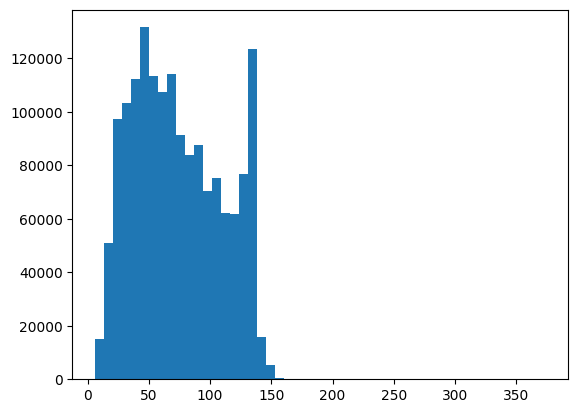

In [16]:
import matplotlib.pyplot as plt

plt.hist(df["text_length"], bins=50)
plt.show()

In [18]:
# Proper spacing and separators so each text entry is clearly separated
for i in range(10):
    print(f"--- Tweet {i+1} ---")
    print(df["text"].iloc[i])
    print("\n")

--- Tweet 1 ---
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D


--- Tweet 2 ---
is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!


--- Tweet 3 ---
@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds


--- Tweet 4 ---
my whole body feels itchy and like its on fire 


--- Tweet 5 ---
@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. 


--- Tweet 6 ---
@Kwesidei not the whole crew 


--- Tweet 7 ---
Need a hug 


--- Tweet 8 ---
@LOLTrish hey  long time no see! Yes.. Rains a bit ,only a bit  LOL , I'm fine thanks , how's you ?


--- Tweet 9 ---
@Tatiana_K nope they didn't have it 


--- Tweet 10 ---
@twittera que me muera ? 




Text Cleaning

In [19]:
import re

In [20]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove www links
    text = re.sub(r"www\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [21]:
df["clean_text"] = df["text"].apply(clean_text)


In [22]:
df[["text","clean_text"]].head(10)

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",a thats a bummer you shoulda got david carr of...
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...
5,@Kwesidei not the whole crew,not the whole crew
6,Need a hug,need a hug
7,@LOLTrish hey long time no see! Yes.. Rains a...,hey long time no see yes rains a bit only a bi...
8,@Tatiana_K nope they didn't have it,nope they didnt have it
9,@twittera que me muera ?,que me muera


In [23]:
(df["clean_text"] == "").sum()

np.int64(3697)

In [26]:
df = df[df["clean_text"] != ""]


In [27]:
df.to_csv(
    "../data/clean_sentiment140.csv",
    index=False
)

In [28]:
df["sentiment"].value_counts()

sentiment
negative    798319
positive    797984
Name: count, dtype: int64

In [30]:
sample_df = df.sample(
    n=100000,
    random_state=42
)

In [33]:
sample_df.to_csv(
    "../data/sentiment140_100k.csv",
    index=False
)

In [35]:
sample_df = df.sample(
    n=30000,
    random_state=42
)

In [36]:
sample_df.to_csv(
    "../data/sentiment140_30k.csv",
    index=False
)

In [37]:
sample_df["sentiment"].value_counts()

sentiment
positive    15106
negative    14894
Name: count, dtype: int64

In [ ]:
sample_path = r"C:\Users\Admin\Desktop\Sentiment Project\data\sentiment140_30k.csv"
if os.path.exists(sample_path):
    df = pd.read_csv(sample_path)
else:
    raise FileNotFoundError(f"File not found at: {sample_path}")
df.head()
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/sentiment140_30k.csv'